In [ ]:
# bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd


In [45]:
#dados

# dados genericos
#X = [0.5, 2.5, 6.5, 8]
#y = [2.0, 2.2, 2.2, 2.45]
#
# kaggle : Student Study Hours

df = pd.read_csv("archive/score_updated.csv")

X = df['Hours'].values
y = df['Scores'].values

In [46]:
# regressão linear simples

# declarando variaveis
lr = 0.01 # lr : taxa de aprendizado
# vê criterios dps para definir w0,w1 iniciais
w0 = 0.1
w1 = 0.1

# hipotese: y* = w0+w1*x
def y_hat(x, w0, w1):
    return w0+ w1*x

In [47]:
# plot dos pontos e regressão
def plot_line(X,y,w0,w1):
    x_values = [i for i in range(int(min(X))-1, int(max(X))+2)]
    y_values = [y_hat(x,w0,w1) for x in x_values]

    plt.plot(x_values,y_values, 'r')
    plt.plot(X,y,'bo')

In [48]:
# função do erro medio quadrado
def mse(X, y, w0, w1):
    cost = 0
    m = float(len(X))

    for i in range(0,len(X)):
        cost += (y_hat(X[i],w0,w1)-y[i])**2

    return cost/m

In [49]:
# função do gradiente descendente
def gradient_descent_step(w0,w1,X,y,lr):
    erro_w0=0
    erro_w1=0
    m = len(X)

    for i in range(0,m): 
        erro_w0 += y_hat(X[i],w0,w1) - y[i]
        erro_w1 += (y_hat(X[i],w0,w1) - y[i]) * X[i]
    
    new_w0 = w0 - lr * (1/m) * erro_w0
    new_w1 = w1 - lr * (1/m) * erro_w1

    return new_w0, new_w1

In [50]:
# looping do gradiente descendente

epoch = 100

def gradient_descent(w0,w1,X,y,lr,epoch):
    cost = np.zeros(epoch)

    cost_anterior = float('inf') # declarada para evitar erro na primeira iteração do looping

    for i in range(epoch):
        w0,w1 = gradient_descent_step(w0,w1,X,y,lr)

        cost_atual = mse(X,y,w0,w1)
        cost[i] = cost_atual

        if abs(cost_atual - cost_anterior) < 1e-6: # 'ponto' de convergencia
            break

        cost_anterior = cost_atual

    return w0,w1,cost
    

Text(0.5, 1.0, 'MSE vs Epoch')

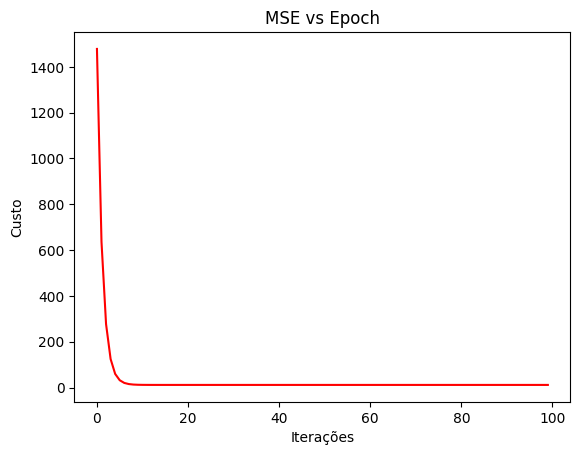

In [51]:
# plot do custo

w0, w1, cost = gradient_descent(w0, w1, X, y, lr, epoch)

fig, ax = plt.subplots()
ax.plot(np.arange(epoch), cost, 'r')
ax.set_xlabel('Iterações')
ax.set_ylabel('Custo')
ax.set_title("MSE vs Epoch")

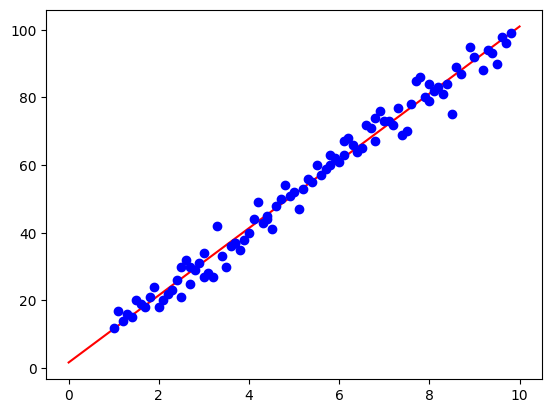

In [52]:
# plot da hipotese

plot_line(X,y,w0,w1)